A principal recovery ratio, defined as `total_rec_prncp` divided by `loan_amnt`, closer to 1 means that more of the original principal was recovered. As illustrated by @fig-eda-visualizations, some defaulted loans still recover a substantial share of principal. We also identify potential features with a correlation matrix.

In [16]:
#| include: false

import kagglehub
import os
import pandas as pd

df_orig = []
file_path = "loan.csv"
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

csv_file = os.path.join(path, "loan.csv")
df_orig = pd.read_csv(csv_file, low_memory=False)

In [17]:
#| label: fig-default-loans-recovery-ratio
#| echo: false
#| warning: false

import matplotlib.pyplot as plt

def generate_default_loans_plot(ax):
    global df_orig

    df = df_orig.copy()

    features = [
        "total_rec_prncp", "loan_amnt", "loan_status"
    ]
    df = df[features]

    default_loans = df[df['loan_status'].isin(['Default', 'Charged Off'])].copy()
    default_loans['recovery_ratio'] = (default_loans['total_rec_prncp'] / default_loans['loan_amnt']) * 100
    
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']
    default_loans['recovery_bucket'] = pd.cut(default_loans['recovery_ratio'], bins=bins, labels=labels)
    bucket_counts = default_loans['recovery_bucket'].value_counts().sort_index()

    ax.bar(bucket_counts.index, bucket_counts.values, color='skyblue', edgecolor='black')
    ax.set_title('Recovery Ratio Distribution of Defaulted Loans')
    ax.set_xlabel('Recovery Ratio (%)')
    ax.set_ylabel('Loans')
    ax.tick_params(axis='x', rotation=45)


In [18]:
#| label: fig-correlation-matrix
#| fig-cap: "Correlation Matrix for Selected Features."
#| echo: false
#| warning: false


import seaborn as sns

def generate_correlation_matrix(ax):

  global df_orig


  features = [
    "total_rec_prncp", "loan_amnt", "loan_status", "grade", "sub_grade",
    "term", "emp_length", "annual_inc"
  ]
  df = df_orig.copy()
  df = df[features]

  grade_order = ["A", "B", "C", "D", "E", "F", "G"]
  df["grade"] = pd.Categorical(df["grade"], categories=grade_order, ordered=True).codes + 1

  sub_grades = [f"{g}{n}" for g in ["A","B","C","D","E","F","G"] for n in range(1, 6)]
  df["sub_grade"] = pd.Categorical(df["sub_grade"], categories=sub_grades, ordered=True).codes + 1


  term_order = [" 36 months", " 60 months"]
  df["term"] = pd.Categorical(df["term"], categories=term_order, ordered=True).codes + 1

  emp_order = ["< 1 year", "1 year", "2 years", "3 years", "4 years",
              "5 years", "6 years", "7 years", "8 years", "9 years", "10+ years"]
  df["emp_length"] = pd.Categorical(df["emp_length"], categories=emp_order, ordered=True).codes
  df["emp_length"] = df["emp_length"].replace(-1, pd.NA)


  status_order = [
    "Fully Paid",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)",
    "Default",
    "Charged Off"
  ]
  df["loan_status"] = pd.Categorical(df["loan_status"], categories=status_order, ordered=True).codes + 1
  df["loan_status"] = df["loan_status"].replace(0, pd.NA)


  df = df.dropna().reset_index(drop=True)


  df = df.assign(recovery_ratio=df["total_rec_prncp"] / df["loan_amnt"])
  df = df[df["recovery_ratio"].notna() & ~df["recovery_ratio"].isin([float("inf"), float("-inf")])]


  corr = df.corr(method="pearson")

  sns.heatmap(
      corr,
      annot=True,
      fmt=".2f",
      cmap="coolwarm",
      center=0,
      vmin=-1, vmax=1,
      linewidths=0.5,
      ax=ax,
      annot_kws={"size": 9}
  )

  ax.set_title("Pearson Correlation Matrix", fontsize=13)
  plt.xticks(rotation=45, ha="right", fontsize=9)
  plt.yticks(rotation=0, fontsize=9)

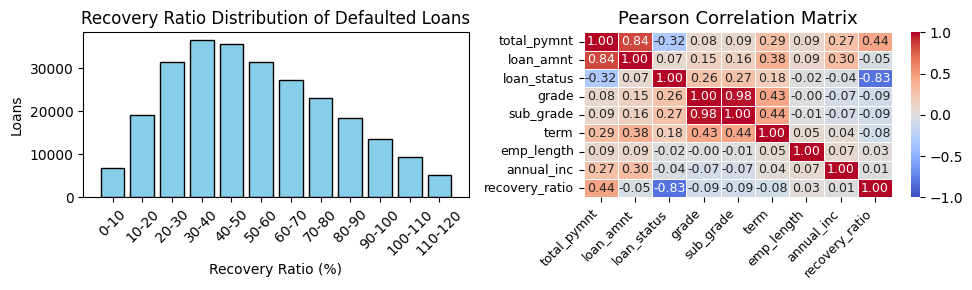

In [20]:
#| label: fig-eda-visualizations
#| fig-subcap: 
#|   - "Recovery Ratio Distribution for Defaulted Loans"
#|   - "Feature Correlation Matrix"
#| echo: false
#| warning: false

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

generate_default_loans_plot(ax=ax1)
generate_correlation_matrix(ax=ax2)

plt.tight_layout()
plt.show()